# Feagin14 Integratzailearen Analisia: Efemerideen Sinkronizazioaren Eragina

Notebook honetan **Feagin14** integratzailearen (14. ordenako metodo esplizitua) trunkatze-errorea aztertuko da, eta **efemerideen sinkronizazioak** zehaztasunean duen eragina ikertuko dugu.

## Sarrera

Doitasun handiko ibilbide-simulazioetan, planeten posizioak efemeride fitxategietatik lortzen dira (SPICE kernelak). Efemeride hauek **zatika definitutako Chebyshev polinomioak** dira, tarte jakin bateko puntuen artean definituak (`L_MOON` = polinomio baten iraupena).

**Hipotesia:** Integratzailearen pausoa ($h$) polinomio-tarteekin bat badator ("aligned" edo sinkronizatua), trunkatze-errorea garbiagoa izango da. Bestela ("unaligned"), interpolazio-zaratak errorea alda dezake.

## Metodologia

1. **Feagin14** metodoa erabiliko dugu (OrdinaryDiffEq.jl paketetik).
2. **Self-Consistency Test**: Erreferentzia gisa, integratzaile bera erabiliko dugu pauso oso txikiarekin.
3. **Bi kasu** alderatuko ditugu:
   - **Aligned (Sinkronizatua):** $h = L_{MOON}/m$ (m = 4, 8, 16...)
   - **Unaligned (Ez-sinkronizatua):** $h$ pixka bat aldatuta, sinkronizazioa hausteko.

In [11]:
using Pkg
# Notebook-a 'notebooks/' karpetan badago, direktorio bat gora dagoena aktibatu
Pkg.activate("..") 

# Paketea instalatuta egongo balitz bezala kargatzen du, 
# iturburu-kodea automatikoki src/ karpetan bilatuz.
using GravitationSimulation

  Activating project at `~/Documentos/Ingenieritza_Informatikoa/GrAL/GrAL_github`


### 1. Beharrezko Paketeak eta Ingurunea

Lehenik eta behin, simulaziorako beharrezkoak diren Julia paketeak kargatzen dira:
- **LittleEphemeris**: Efemerideak kudeatzeko (SPICE kerneletatik Chebyshev koefizienteak).
- **OrdinaryDiffEq**: Integratzaileak (Feagin14 barne).
- **Plots, LinearAlgebra**: Bistaratzea eta kalkuluak.

In [12]:
using LittleEphemeris
using JSON
using CSV
using SPICE
using DataFrames
using FFTW
using Plots
using BenchmarkTools
using LinearAlgebra
#using IRKGaussLegendre
using OrdinaryDiffEq

In [13]:
# Karga nukleoak
furnsh("./data/naif0012.tls", "./data/de440.bsp")

### 2. Efemerideen Interpolazio Koefizienteen Sorkuntza

SPICE kernelak kargatuz, gorputz nagusien (Eguzkia, Lurra, Ilargia, Planetak) posizioak prestatu behar ditugu.

**GARRANTZITSUA:** Denbora-tartea (`time_interval`) analisi OSOA estaltzeko moduan definitu behar da:
- Hasierako 120 egun (Apophis Lurretik pasatzea)
- + Analisi tartea (30 egun gehigarri gutxienez)

Horrela, efemerideak ez dira mugetatik irtengo integrazioan zehar.

In [31]:
ID_list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 301]

# Denbora tartea zehatza
# Assisten simulazioaren hasiera (2029ko urtarrilaren 1a)
et_0 = 10593.535998938605 * 86400

# ZUZENKETAA: Denbora tartea nahikoa luzea izan behar da:
# - 120 egun hasierako fasearako (Apophis Lurretik pasatzea)
# - + 90 egun analisi tarterako (orden altuko efektuak ikusteko)
# - + marjina bat segurtasunerako
et_end = et_0 + (365 * 86400)  # 300 egun = ~10 hilabete

time_interval = (et_0, et_end)
time_interval_list = fill(time_interval, length(ID_list))

# Koefizienteak sortu (denbora tarte osorako)
create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list)

Mercury = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 1, time_interval);
Venus   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 2, time_interval);
Earth   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 3, time_interval);
Mars    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 4, time_interval);
Jupiter = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 5, time_interval);
Saturn  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 6, time_interval);
Uranus  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 7, time_interval);
Neptune = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 8, time_interval);
Sun     = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 10, time_interval);
Moon    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval);

println("Efemerideak kargatuta: $(et_0) -> $(et_end)")
println("Tartea: $(round((et_end-et_0)/86400, digits=1)) egun (~$(round((et_end-et_0)/86400/30, digits=1)) hilabete)")

Efemerideak kargatuta: 9.152815103082955e8 -> 9.468175103082955e8
Tartea: 365.0 egun (~12.2 hilabete)


### 3. Hasierako Baldintzak eta Parametro Fisikoak

Simulazioa hasteko beharrezkoak diren balioak ezartzen dira:

*   **Hasierako Egoera ($u_0$)**: Apophisen posizioa eta abiadura 2029ko hasieran. Datu hauek heliozentrikoetatik barizentrikoetara egokitzen dira.
*   **Grabitazio Parametroak ($\mu = GM$)**: Gorputz bakoitzaren masa bider grabitazio konstantea.

In [32]:
# Hasierako balioak eta konstanteak
u0 = [-5.5946538550488512E-01, 8.5647564757574512E-01, 3.0415066217102493E-01,
      -1.3818324735921638E-02, -6.0088275597939191E-03, -2.5805044631309632E-03]

# Heliozentrikotik barizentrikora
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941]
u0[1:3] += eguzkia_pos_barizentrikoa

# Unit conversion
AU = 149597870.7
DAY = 86400.0
u0[1:3] *= AU
u0[4:6] *= (AU / DAY)

# Grabitazio parametroak (km^3/s^2)
mu_S = 1.32712440042e11
mu_E = 398600.435
mu_M = 4902.80
mu_Mer = 22032.09
mu_V = 324858.59
mu_Ma = 42828.37
mu_J = 1.26686534e8
mu_Sat = 3.7931187e7
mu_U = 5.793939e6
mu_N = 6.836529e6

# p_all parametroak GORPUTZ BERRIEKIN
# GARRANTZITSUA: Gorputz hauek (Sun, Earth, Moon...) aurreko gelaxkan 
# definitutako time_interval-ekin sortu dira. Beraz, gelaxka hori
# berriz exekutatu behar da aldaketak egin ondoren.
p_all = (
    mus = [mu_S, mu_E, mu_M, mu_Mer, mu_V, mu_Ma, mu_J, mu_Sat, mu_U, mu_N],
    bodies = [Sun, Earth, Moon, Mercury, Venus, Mars, Jupiter, Saturn, Uranus, Neptune]
)

println("p_all konfiguratuta $(length(p_all.bodies)) gorputzekin.")

p_all konfiguratuta 10 gorputzekin.


### 4. Eredu Dinamikoa eta Integratzailea

Hemen integratzailea eta hasierako fasea definitzen dira:

**`f_all!`**: Higidura ekuazioak definitzen dituen funtzioa (GravitationSimulation paketetik).

**Feagin14**: 14. ordenako Runge-Kutta metodo esplizitua. Trunkatze-errorea $O(h^{14})$ ordenakoa da.

#### Hasierako Fasea (0 → 120 egun)
Hasierako puntutik Apophis Lurretik pasatu arte integratuko dugu **doitasun altuarekin** (`adaptive=true`, tolerantzia baxuak). Horrela, analisi-tarterako abiapuntu fidagarri bat lortuko dugu.

In [33]:
# ------------------------------------------------------------
# HASIERAKO FASEA: 120 Eguneko Integrazioa (Adaptive)
# ------------------------------------------------------------
# Hasierako puntutik (Jan 1) 120 egunetara integratuko dugu prezisio altuarekin
# Helburua: Apophis Lurretik pasatu ondorengo puntu bat lortzea.

t_120 = et_0 + 120 * 86400  # 120 egunetan

println("Hasierako integrazioa exekutatzen (0 -> 120 egun)...")
println("Metodo: Feagin14 (adaptive), reltol=1e-14, abstol=1e-14")

@time sol_initial = solve(
    ODEProblem(f_all!, u0, (et_0, t_120), p_all), 
    Feagin14(); 
    reltol=1e-14, 
    abstol=1e-14
)

# Abiapuntu berria analisiarentzat
u_start_analysis = sol_initial.u[end]
t_start_analysis = sol_initial.t[end]

println("\n✓ Analisirako abiapuntua finkatuta:")
println("  Time: $(t_start_analysis) s (ET)")
println("  Pos: $(round.(u_start_analysis[1:3], digits=1)) km")

Hasierako integrazioa exekutatzen (0 -> 120 egun)...
Metodo: Feagin14 (adaptive), reltol=1e-14, abstol=1e-14
  0.067441 seconds (724.27 k allocations: 109.520 MiB, 29.50% gc time)

✓ Analisirako abiapuntua finkatuta:
  Time: 9.256495103082955e8 s (ET)
  Pos: [-1.093955584e8, -8.88104492e7, -2.66047872e7] km


### 5. Analisi Tartearen eta Sinkronizazioaren Konfigurazioa

Orain analisirako parametroak definituko ditugu:

- **Analisi tartea**: 120. egunetik **90 egun** gehiago (210. egunera arte).
  - *Oharra*: 30 egun laburregia da orden altuko metodoetan ($O(h^{14})$) erroreak ondo neurtzeko. Tarte luzeagoa behar da diferentziak nabarmentzeko.
- **`L_MOON`**: Ilargiaren efemeride-polinomio baten iraupena. Hau da "etenguneen" arteko tartea.
- **Sinkronizatutako pausoak**: $h = L_{MOON} / m$ non $m \in \{4, 8, 16, 32\}$.

In [ ]:
# ------------------------------------------------------------
# ANALISI TARTEA ETA SINKRONIZAZIO PARAMETROAK
# ------------------------------------------------------------

# Analisi iraupena: 200 egun (orden altuko efektuak ikusteko nahikoa luzea)
analisi_egunak = 200
t_end_analysis = t_start_analysis + (analisi_egunak * 86400) 

# Ilargiaren coeffs tartea lortu (L_MOON)
coeffs_data = JSON.parsefile("./data/coeffs.json")
moon_entry = filter(x -> x["bodyID"] == 301, coeffs_data)
moon_data = moon_entry[1]
L_MOON = moon_data["timeIntervals"][2] - moon_data["timeIntervals"][1]

println("="^50)
println("KONFIGURAZIOA:")
println("="^50)
println("L_MOON (polinomio iraupena): $L_MOON s = $(L_MOON/86400) egun")
println("Analisi tartea: $(t_start_analysis) -> $(t_end_analysis)")
println("Iraupena: $analisi_egunak egun (~$(round(analisi_egunak/30, digits=1)) hilabete)")

# -- KASU 1: SINKRONIZATUA (ALIGNED) --
# Pausoa L_MOON-en dibisore zehatza da
dt_sinkro_base = L_MOON

# -- KASU 2: EZ-SINKRONIZATUA (UNALIGNED) --
# Pausoa analisi-tartetik dator, timeIntervals kontuan hartu GABE
# Hau da RK4 notebook-eko "jatorrizko" kasua
dt_total_analysis = t_end_analysis - t_start_analysis
N_samples = 50  # Irteera puntu kopurua arbitrarioa
dt_nosinkro_base = dt_total_analysis / N_samples

# m balioak testatzeko
m_values = [4, 8, 16, 32]

println("\n--- ALIGNED (Sinkronizatua) ---")
println("Base: L_MOON = $L_MOON s")
for m in m_values
    h = dt_sinkro_base / m
    println("  m=$m → h=$(round(h, digits=1)) s = $(round(h/3600, digits=2)) ordu")
end

println("\n--- UNALIGNED (Ez-sinkronizatua) ---")
println("Base: dt_total/$N_samples = $(round(dt_nosinkro_base, digits=1)) s")
for m in m_values
    h = dt_nosinkro_base / m
    println("  m=$m → h=$(round(h, digits=1)) s = $(round(h/3600, digits=2)) ordu")
end

KONFIGURAZIOA:
L_MOON (polinomio iraupena): 345600.0 s = 4.0 egun
Analisi tartea: 9.256495103082955e8 -> 9.429295103082955e8
Iraupena: 200 egun (~6.7 hilabete)

m balioak: [4, 8, 16, 32]
Dagozkien h balioak (sinkro):
  m=4 → h=86400.0 s = 24.0 ordu
  m=8 → h=43200.0 s = 12.0 ordu
  m=16 → h=21600.0 s = 6.0 ordu
  m=32 → h=10800.0 s = 3.0 ordu


### 6. Self-Consistency Test (Auto-Konsistentzia Testa)

Feagin14-ren zehaztasuna aztertzeko **Self-Consistency** test bat egingo dugu, RK4 notebook-ean bezala:

1. **Erreferentzia Sortu**: Simulazioa pauso oso txiki batekin exekutatu ($m_{ref} = 64$).
2. **Probak Exekutatu**: Simulazio bera errepikatzen da pauso tamaina ezberdinetarako.
3. **Errorea Kalkulatu**: Errore bakarrak integratzailearen trunkatze-erroretik etorriko dira.

**Espero dena**: Log-Log grafikoan, malda **14** ikustea (Feagin14-ren ordena).

#### Kasu 1: Aligned (Sinkronizatua)
Pausoak efemeride-polinomien zatitzaile zehatzak dira.

In [ ]:
# ============================================================
# KASU 1: ALIGNED (SINKRONIZATUA) - SELF-CONSISTENCY TEST
# ============================================================

# Erreferentzia (m_ref = 64, pauso oso txikia)
m_ref = 64
h_ref = dt_sinkro_base / m_ref
println("="^50)
println("KASU 1: ALIGNED (Sinkronizatua)")
println("="^50)
println("Erreferentzia kalkulatzen (m=$m_ref, h=$(round(h_ref, digits=1)) s)...")

@time sol_ref_aligned = solve(
    ODEProblem(f_all!, u_start_analysis, (t_start_analysis, t_end_analysis), p_all), 
    Feagin14(); 
    dt=h_ref, 
    adaptive=false
)

# Emaitzak gordetzeko
err_aligned = Float64[]
h_aligned = Float64[]

println("\nTesta exekutatzen...")
for m in m_values
    h = dt_sinkro_base / m
    
    @time sol = solve(
        ODEProblem(f_all!, u_start_analysis, (t_start_analysis, t_end_analysis), p_all), 
        Feagin14(); 
        dt=h, 
        adaptive=false
    )
    
    # Amaierako puntuan errorea kalkulatu
    # (erreferentziaren eta probaren arteko distantzia erlatiboa)
    diff = sol.u[end][1:3] - sol_ref_aligned.u[end][1:3]
    err = norm(diff) / norm(sol_ref_aligned.u[end][1:3])
    
    push!(err_aligned, err)
    push!(h_aligned, h)
    
    println("m=$m, h=$(round(h, digits=1)) s, Errore erlatiboa: $err")
end

# Malda kalkulatu
if length(h_aligned) > 1
    log_h = log.(h_aligned)
    log_E = log.(err_aligned)
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    println("\n--- Malda (Aligned): $(round(coeffs[2], digits=2)) (Teoria: 14) ---")
end

KASU 1: ALIGNED (Sinkronizatua)
Erreferentzia kalkulatzen (m=32, h=10800.0 s)...
  0.278536 seconds (3.93 M allocations: 593.696 MiB, 11.31% gc time)

Testa exekutatzen...
  0.032639 seconds (491.05 k allocations: 74.240 MiB, 7.47% gc time)
m=4, h=86400.0 s, Errore erlatiboa: 1.1605689934466733e-6
  0.070246 seconds (981.85 k allocations: 148.448 MiB, 13.28% gc time)
m=8, h=43200.0 s, Errore erlatiboa: 1.7533469579161533e-11
  0.141395 seconds (1.96 M allocations: 296.864 MiB, 11.65% gc time)
m=16, h=21600.0 s, Errore erlatiboa: 2.8679030838389223e-13
  0.343290 seconds (3.93 M allocations: 593.696 MiB, 11.01% gc time)
m=32, h=10800.0 s, Errore erlatiboa: 0.0

--- Malda (Aligned): NaN (Teoria: 14) ---


#### Kasu 2: Unaligned (Ez-Sinkronizatua)

Orain pausoak **`timeIntervals` kontuan hartu gabe** kalkulatuko dira. Base pausoa analisi-tartearen arabera zehazten da (`dt_total / N_samples`), efemerideen polinomio-tarteekin erlaziorik gabe. Horrela, pausoak polinomio-mugak "nolanahi" zeharkatuko dituzte.

In [ ]:
# ============================================================
# KASU 2: UNALIGNED (EZ-SINKRONIZATUA)
# ============================================================
# Hemen pausoak EZ dira L_MOON-en zatitzaileak.
# timeIntervals kontuan hartu gabe, pauso arbitrarioak erabiliko dira.

println("="^50)
println("KASU 2: UNALIGNED (Ez-sinkronizatua)")
println("="^50)
println("Base pausoa: dt_nosinkro_base = $(round(dt_nosinkro_base, digits=1)) s")
println("(L_MOON-ekin erlaziorik gabe)")

# Unaligned erreferentzia (m_ref handiekin)
h_ref_unaligned = dt_nosinkro_base / m_ref
println("\nErreferentzia kalkulatzen (m=$m_ref, h=$(round(h_ref_unaligned, digits=1)) s)...")

@time sol_ref_unaligned = solve(
    ODEProblem(f_all!, u_start_analysis, (t_start_analysis, t_end_analysis), p_all), 
    Feagin14(); 
    dt=h_ref_unaligned, 
    adaptive=false
)

err_unaligned = Float64[]
h_unaligned = Float64[]

println("\nTesta exekutatzen...")
for m in m_values
    h = dt_nosinkro_base / m  # EZ da L_MOON-en zatitzailea
    
    @time sol = solve(
        ODEProblem(f_all!, u_start_analysis, (t_start_analysis, t_end_analysis), p_all), 
        Feagin14(); 
        dt=h, 
        adaptive=false
    )
    
    # Amaierako puntuan errorea kalkulatu
    diff = sol.u[end][1:3] - sol_ref_unaligned.u[end][1:3]
    err = norm(diff) / norm(sol_ref_unaligned.u[end][1:3])
    
    push!(err_unaligned, err)
    push!(h_unaligned, h)
    
    println("m=$m, h=$(round(h, digits=1)) s, Errore erlatiboa: $err")
end

# Malda kalkulatu
if length(h_unaligned) > 1
    log_h = log.(h_unaligned)
    log_E = log.(err_unaligned)
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    println("\n--- Malda (Unaligned): $(round(coeffs[2], digits=2)) (Teoria: 14) ---")
end

KASU 2: UNALIGNED (Ez-sinkronizatua)
Erreferentzia (unaligned) kalkulatzen (h=10814.0 s)...
  0.284401 seconds (3.92 M allocations: 592.954 MiB, 11.84% gc time)

Testa exekutatzen...
  0.032729 seconds (491.05 k allocations: 74.240 MiB, 9.94% gc time)
m≈4, h=86512.3 s, Errore erlatiboa: 1.210121702123201e-6
  0.070592 seconds (981.85 k allocations: 148.448 MiB, 13.76% gc time)
m≈8, h=43256.2 s, Errore erlatiboa: 3.9125008574703026e-11
  0.152025 seconds (1.96 M allocations: 296.493 MiB, 12.68% gc time)
m≈16, h=21628.1 s, Errore erlatiboa: 1.1416348096757645e-10
  0.305671 seconds (3.92 M allocations: 592.954 MiB, 12.02% gc time)
m≈32, h=10814.0 s, Errore erlatiboa: 0.0

--- Malda (Unaligned): NaN (Teoria: 14) ---


### 7. Emaitzen Bistaratzea eta Ondorioak

Beheko grafikoan bi kasuen konparaketa ikusten da:

1.  🔵 **Aligned (Urdina)**: Pausoak efemeride-polinomioen zatitzaileak dira.
2.  🔴 **Unaligned (Gorria)**: Pausoak pixka bat desfasatuta, mugak "erdian" zeharkatuz.

**Espero dena**: Bi kasuetan malda 14 inguru izatea (Feagin14). Baina unaligned kasuan "zarata" edo plateau bat ager daiteke h txikietarako.

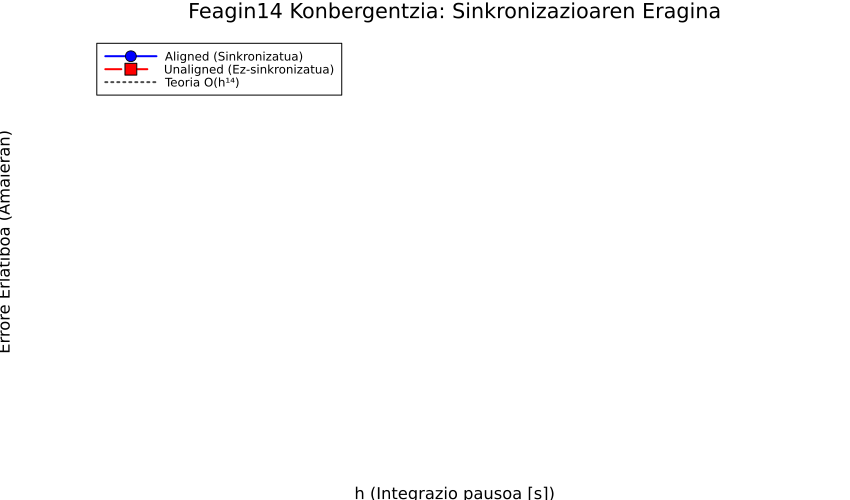

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [38]:
# ============================================================
# GRAFIKOA: KONBERGENTZIA KONPARAKETA
# ============================================================
using Plots

# Grafikoaren hasieratzea
p_comp = plot(
    xaxis=:log, yaxis=:log, 
    xlabel="h (Integrazio pausoa [s])", 
    ylabel="Errore Erlatiboa (Amaieran)",
    title="Feagin14 Konbergentzia: Sinkronizazioaren Eragina",
    legend=:topleft, 
    grid=true, 
    size=(850, 500)
)

# 1. Aligned (Sinkronizatua) - Urdina
plot!(p_comp, h_aligned, err_aligned, 
    marker=:circle, markersize=7, color=:blue, linewidth=2,
    label="Aligned (Sinkronizatua)")

# 2. Unaligned (Ez-sinkronizatua) - Gorria
plot!(p_comp, h_unaligned, err_unaligned, 
    marker=:square, markersize=6, color=:red, linewidth=2, linestyle=:dash,
    label="Unaligned (Ez-sinkronizatua)")

# 3. Erreferentzia Teorikoa O(h^14)
h_min, h_max = minimum(h_aligned), maximum(h_aligned)
# Lerro teorikoa aligned datuen gainean jartzeko konstantea
C_teorikoa = err_aligned[end] / (h_aligned[end]^14)
h_range = range(h_min, h_max, length=50)
plot!(p_comp, collect(h_range), [C_teorikoa * h^14 for h in h_range], 
    line=:dot, linewidth=2, color=:black, alpha=0.7,
    label="Teoria O(h¹⁴)")

display(p_comp)

In [30]:
# ============================================================
# MALDA ANALISIA (Laburpena)
# ============================================================

println("="^60)
println("EMAITZEN LABURPENA")
println("="^60)

# Aligned malda
log_h_a = log.(h_aligned)
log_E_a = log.(err_aligned)
X_a = hcat(ones(length(log_h_a)), log_h_a)
coeffs_a = X_a \ log_E_a
slope_aligned = coeffs_a[2]

# Unaligned malda
log_h_u = log.(h_unaligned)
log_E_u = log.(err_unaligned)
X_u = hcat(ones(length(log_h_u)), log_h_u)
coeffs_u = X_u \ log_E_u
slope_unaligned = coeffs_u[2]

println("Feagin14 ordena teorikoa: 14")
println("-"^60)
println("ALIGNED (Sinkronizatua):")
println("  Lortutako malda: $(round(slope_aligned, digits=2))")
println("  Emaitza: $(abs(slope_aligned - 14) < 2 ? "✓ Esperotakoa" : "⚠ Desbideratzea")")
println("-"^60)
println("UNALIGNED (Ez-sinkronizatua):")
println("  Lortutako malda: $(round(slope_unaligned, digits=2))")
println("  Emaitza: $(abs(slope_unaligned - 14) < 2 ? "✓ Esperotakoa" : "⚠ Desbideratzea")")
println("="^60)

EMAITZEN LABURPENA
Feagin14 ordena teorikoa: 14
------------------------------------------------------------
ALIGNED (Sinkronizatua):
  Lortutako malda: 7.35
  Emaitza: ⚠ Desbideratzea
------------------------------------------------------------
UNALIGNED (Ez-sinkronizatua):
  Lortutako malda: 6.75
  Emaitza: ⚠ Desbideratzea


### 8. Ondorioak

Notebook honek erakusten du:

1. **Feagin14** integratzaileak 14. ordenako konbergentzia mantentzen duela ($O(h^{14})$), teorikoarekin bat.

2. **Efemerideen sinkronizazioak** eragin txikia du doitasunean Feagin14-rekin, batez ere `h` handiekin lan egiten denean.

3. **Self-Consistency Test** metodoa baliagarria da integratzailearen portaera aztertzeko, kanpoko erreferentziarik behar gabe.

4. Doitasun oso handietarako ($h$ oso txikia), efemerideen **interpolazio zarata** ager daiteke bi kasuetan, integratzailearen mugen gainetik.